# Parcel Network Forecasting & Capacity Optimization

**Portfolio case study — synthetic data**

This project demonstrates an end-to-end data-science workflow for parcel logistics:

1. Explore parcel volumes across a small terminal network.
2. Build time-series features and compare forecasting approaches.
3. Forecast near-term parcel demand.
4. Convert the forecast into an operational capacity decision.
5. Use mixed-integer optimization to choose extra staffing and inter-terminal volume transfers.
6. Visualize the resulting network decisions geographically.

> **Important:** All parcel volumes, terminal capacities, costs, and operational assumptions in this case study are synthetic. The project is inspired by common parcel-logistics planning problems and does not use proprietary company data.

## Business question

A parcel operator manages six regional terminals. Daily parcel volumes vary by weekday, season, local demand, and campaign effects. If forecast demand exceeds terminal capacity, the operator can:

- add temporary staff,
- use overtime-like extra capacity,
- transfer a limited share of parcels to another terminal,
- or accept a costly capacity shortage.

The objective is to use forecasts to make a practical next-day capacity plan at minimum expected cost.


## 1. Imports and reproducibility

The workflow uses:

- **pandas / NumPy** for data preparation,
- **scikit-learn** for machine-learning forecasting,
- **SciPy MILP** for capacity optimization,
- **Plotly** for interactive analytical plots,
- **GeoPandas / Matplotlib** for the fixed geographic decision map.


In [35]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from scipy.optimize import milp, LinearConstraint, Bounds

pio.renderers.default = "notebook_connected"

In [36]:
DATA_DIR = Path(".")
volume_path = DATA_DIR / "parcel_volume_synthetic.csv"
terminal_path = DATA_DIR / "terminals_synthetic.csv"

volumes = pd.read_csv(volume_path, parse_dates=["date"])
terminals = pd.read_csv(terminal_path)

volumes.head()

,date,terminal,parcel_volume,weekday,month,is_weekend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2026-01-01,Gavle,2665,3,1,0,NaN,NaN,NaN,NaN,NaN
1,2026-01-02,Gavle,3018,4,1,0,2665.0,NaN,NaN,NaN,NaN
2,2026-01-03,Gavle,1977,5,1,1,3018.0,NaN,NaN,NaN,NaN
3,2026-01-04,Gavle,1575,6,1,1,1977.0,NaN,NaN,NaN,NaN
4,2026-01-05,Gavle,2953,0,1,0,1575.0,NaN,NaN,NaN,NaN


## 2. Understand the synthetic network

The six terminals are placed in Swedish cities to create a realistic geographic setting, but they are **fictional logistics facilities**.

Each terminal has:

- a normal daily processing capacity,
- extra capacity contributed by each temporary worker,
- a limit on temporary workers,
- a synthetic daily worker cost.


In [37]:
terminals


,terminal,lat,lon,base_capacity,worker_capacity,max_extra_workers,worker_cost_sek
0,Stockholm,59.3293,18.0686,9000,600,6,1700
1,Uppsala,59.8586,17.6389,5200,520,5,1450
2,Vasteras,59.6099,16.5448,4700,500,5,1380
3,Sodertalje,59.1955,17.6253,4300,500,4,1360
4,Orebro,59.2753,15.2134,4500,520,5,1400
5,Gavle,60.6749,17.1413,3900,480,4,1320


In [38]:
summary = (
    volumes.groupby("terminal")["parcel_volume"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(0)
)
summary


,count,mean,std,min,max
terminal,,,,,
Gavle,240,3197.0,838.0,1402,5927
Orebro,240,3730.0,932.0,1776,5937
Sodertalje,240,3511.0,886.0,1571,6129
Stockholm,240,8041.0,1969.0,3729,12014
Uppsala,240,4373.0,1117.0,2085,8091
Vasteras,240,3802.0,954.0,1566,6005


In [39]:
daily_total = volumes.groupby("date", as_index=False)["parcel_volume"].sum()

fig = px.line(
    daily_total,
    x="date",
    y="parcel_volume",
    title="Total parcel volume across the synthetic network",
    labels={"date": "Date", "parcel_volume": "Parcels"},
    template="plotly_white",
)
fig.update_traces(line={"color": "#2563EB", "width": 2})
fig.update_layout(
    height=430,
    hovermode="x unified",
    margin={"l": 40, "r": 24, "t": 70, "b": 40},
)
fig.show()


### Operational interpretation

The series contains:

- strong **weekday effects**,
- slower seasonal changes,
- gradual trend,
- terminal-specific variation,
- a few synthetic campaign spikes.

This matters because a naive average can miss recurring demand patterns. A forecasting model should therefore use lagged demand and calendar features.


## 3. Feature engineering

For every terminal, create:

- parcel volume 1 day ago,
- parcel volume 7 days ago,
- parcel volume 14 days ago,
- rolling 7-day mean and standard deviation,
- weekday, month, and weekend indicator.

These are all features that would be available before the next-day planning decision.


In [40]:
data = volumes.copy()

# The CSV already contains these engineered features, but we rebuild them here
# so that the notebook shows the full workflow.
data = data[["date", "terminal", "parcel_volume"]].sort_values(["terminal", "date"])

data["weekday"] = data["date"].dt.weekday
data["month"] = data["date"].dt.month
data["is_weekend"] = (data["weekday"] >= 5).astype(int)

for lag in [1, 7, 14]:
    data[f"lag_{lag}"] = data.groupby("terminal")["parcel_volume"].shift(lag)

data["rolling_mean_7"] = (
    data.groupby("terminal")["parcel_volume"]
    .transform(lambda s: s.shift(1).rolling(7).mean())
)

data["rolling_std_7"] = (
    data.groupby("terminal")["parcel_volume"]
    .transform(lambda s: s.shift(1).rolling(7).std())
)

model_data = data.dropna().copy()
model_data.head()


,date,terminal,parcel_volume,weekday,month,is_weekend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
14,2026-01-15,Gavle,2360,3,1,0,2775.0,2618.0,2665.0,2622.142857,638.329442
15,2026-01-16,Gavle,2844,4,1,0,2360.0,3473.0,3018.0,2585.285714,646.010762
16,2026-01-17,Gavle,1725,5,1,1,2844.0,1900.0,1977.0,2495.428571,536.400925
17,2026-01-18,Gavle,1402,6,1,1,1725.0,1654.0,1575.0,2470.428571,571.694224
18,2026-01-19,Gavle,3031,0,1,0,1402.0,2975.0,2953.0,2434.428571,635.992363


## 4. Time-based train/test split

A logistics forecasting model must be evaluated on the **future**, not on randomly shuffled observations.

The last 40 days are therefore held out as a test period.


In [41]:
test_days = 40
cutoff = model_data["date"].max() - pd.Timedelta(days=test_days - 1)

train = model_data[model_data["date"] < cutoff].copy()
test = model_data[model_data["date"] >= cutoff].copy()

print("Training period:", train["date"].min().date(), "to", train["date"].max().date())
print("Test period:", test["date"].min().date(), "to", test["date"].max().date())
print("Training rows:", len(train), "| Test rows:", len(test))


Training period: 2026-01-15 to 2026-07-19
Test period: 2026-07-20 to 2026-08-28
Training rows: 1116 | Test rows: 240


## 5. Baseline forecast

A useful forecasting project should not jump directly to machine learning. First create a transparent benchmark.

Here the baseline is:

> **next demand ≈ demand on the same weekday one week earlier**

That is simply `lag_7`.


In [42]:
y_test = test["parcel_volume"]
baseline_pred = test["lag_7"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5

pd.DataFrame({
    "model": ["7-day lag baseline"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse]
}).round(1)


,model,MAE,RMSE
0,7-day lag baseline,465.6,657.8


## 6. Machine-learning forecast

A Random Forest is used as a practical nonlinear benchmark. It can learn interactions between:

- recent demand,
- weekly lag,
- rolling statistics,
- weekday/month,
- terminal identity.

For a production forecasting system, I would also consider SARIMA, gradient boosting, probabilistic forecasts, hierarchical forecasting, and explicit holiday/event features.


In [43]:
target = "parcel_volume"

numeric_features = [
    "weekday",
    "month",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
]
categorical_features = ["terminal"]

X_train = train[numeric_features + categorical_features]
y_train = train[target]

X_test = test[numeric_features + categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

model = Pipeline([
    ("preprocess", preprocess),
    ("model", rf),
])

model.fit(X_train, y_train)
rf_pred = model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5

metrics = pd.DataFrame({
    "model": ["7-day lag baseline", "Random Forest"],
    "MAE": [baseline_mae, rf_mae],
    "RMSE": [baseline_rmse, rf_rmse],
}).round(1)

metrics


,model,MAE,RMSE
0,7-day lag baseline,465.6,657.8
1,Random Forest,424.2,602.8


In [44]:
comparison = test[["date", "terminal", "parcel_volume"]].copy()
comparison["baseline"] = baseline_pred.values
comparison["random_forest"] = rf_pred

network_daily = comparison.groupby("date", as_index=False).agg(
    actual=("parcel_volume", "sum"),
    baseline=("baseline", "sum"),
    random_forest=("random_forest", "sum"),
)

fig = go.Figure()
series = [
    ("actual", "Actual", "#0F172A", 3, None),
    ("baseline", "7-day baseline", "#00A816", 2, "dot"),
    ("random_forest", "Random Forest", "#2563EB", 2, None),
]
for column, label, color, width, dash in series:
    fig.add_trace(go.Scatter(
        x=network_daily["date"],
        y=network_daily[column],
        mode="lines",
        name=label,
        line={"color": color, "width": width, "dash": dash},
        hovertemplate=f"{label}: %{{y:,.0f}} parcels<extra></extra>",
    ))

fig.update_layout(
    title="Network-level demand: actual vs forecast",
    xaxis_title="Date",
    yaxis_title="Parcels",
    template="plotly_white",
    height=460,
    hovermode="x unified",
    legend={"orientation": "h", "y": 1.12, "x": 0},
    margin={"l": 40, "r": 24, "t": 90, "b": 40},
)
fig.show()


## 7. Forecast next-day parcel volume

The forecasting model is now refit on all available historical observations.

For each terminal, we construct the features that would be known before the next day begins.


In [45]:
model.fit(
    model_data[numeric_features + categorical_features],
    model_data[target]
)

next_date = data["date"].max() + pd.Timedelta(days=1)

future_rows = []

for terminal, group in data.groupby("terminal"):
    g = group.sort_values("date").copy()
    history = g["parcel_volume"].to_numpy()

    future_rows.append({
        "terminal": terminal,
        "weekday": next_date.weekday(),
        "month": next_date.month,
        "is_weekend": int(next_date.weekday() >= 5),
        "lag_1": history[-1],
        "lag_7": history[-7],
        "lag_14": history[-14],
        "rolling_mean_7": history[-7:].mean(),
        "rolling_std_7": history[-7:].std(ddof=1),
    })

future = pd.DataFrame(future_rows)
future["forecast_volume"] = model.predict(
    future[numeric_features + categorical_features]
).round().astype(int)

forecast = terminals.merge(
    future[["terminal", "forecast_volume"]],
    on="terminal",
    how="left"
)

forecast["capacity_gap_before_action"] = (
    forecast["forecast_volume"] - forecast["base_capacity"]
)

forecast[
    ["terminal", "forecast_volume", "base_capacity", "capacity_gap_before_action"]
].sort_values("capacity_gap_before_action", ascending=False)


,terminal,forecast_volume,base_capacity,capacity_gap_before_action
4,Orebro,3454,4500,-1046
5,Gavle,2720,3900,-1180
0,Stockholm,7746,9000,-1254
3,Sodertalje,3011,4300,-1289
1,Uppsala,3654,5200,-1546
2,Vasteras,3150,4700,-1550


## 8. Turn forecasts into a capacity-planning problem

A forecast is only useful if it changes a decision.

For the next day, the operator may:

1. add temporary workers at each terminal,
2. transfer some forecast parcel volume between terminals,
3. accept a remaining shortage at a high penalty.

### Decision variables

For terminal $i$:

- $w_i$: integer number of extra workers,
- $s_i$: unserved / shortage volume.

For a directed transfer $i \rightarrow j$:

- $t_{ij}$: parcels transferred from terminal $i$ to terminal $j$.

### Objective

Minimize:

$$
\min \quad
\sum_i c_i^{w} w_i
+ \sum_{i \ne j} c_{ij}^{t} t_{ij}
+ \sum_i c_i^{s} s_i
$$

### Capacity constraint

For every terminal:

$$
C_i + q_i w_i
+ \sum_{j \ne i} t_{ij}
- \sum_{j \ne i} t_{ji}
+ s_i
\ge \hat{D}_i,
\qquad \forall i
$$

where $C_i$ is base capacity, $q_i$ is the capacity added per worker, and $\hat{D}_i$ is forecast demand.

Here, outbound transfers reduce the volume that must be processed at the origin, while inbound transfers increase the load at the destination.

Transfers are deliberately capped so the optimizer cannot unrealistically move the entire network.


In [46]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1 = math.radians(lat1)
    p2 = math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = (
        math.sin(dphi / 2) ** 2
        + math.cos(p1) * math.cos(p2) * math.sin(dlambda / 2) ** 2
    )
    return 2 * R * math.asin(math.sqrt(a))

terminal_names = forecast["terminal"].tolist()
n = len(terminal_names)

distance = {}
for i in range(n):
    for j in range(n):
        if i == j:
            continue
        a = forecast.iloc[i]
        b = forecast.iloc[j]
        distance[(i, j)] = haversine_km(a.lat, a.lon, b.lat, b.lon)

pd.DataFrame([
    {
        "from": terminal_names[i],
        "to": terminal_names[j],
        "distance_km": round(d, 1),
    }
    for (i, j), d in distance.items()
]).head()


,from,to,distance_km
0,Stockholm,Uppsala,63.6
1,Stockholm,Vasteras,91.6
2,Stockholm,Sodertalje,29.3
3,Stockholm,Orebro,162.2
4,Stockholm,Gavle,158.3


In [47]:
# Variable layout:
# workers: n integer variables
# transfers: n*(n-1) continuous variables
# shortage: n continuous variables

worker_idx = {i: i for i in range(n)}
transfer_pairs = list(distance.keys())
transfer_idx = {
    pair: n + k for k, pair in enumerate(transfer_pairs)
}
shortage_start = n + len(transfer_pairs)
shortage_idx = {
    i: shortage_start + i for i in range(n)
}
num_vars = shortage_start + n

c = np.zeros(num_vars)

# Worker cost
for i in range(n):
    c[worker_idx[i]] = forecast.iloc[i]["worker_cost_sek"]

# Synthetic transfer cost: SEK per parcel-km
transfer_cost_per_parcel_km = 0.018
for pair, idx in transfer_idx.items():
    c[idx] = distance[pair] * transfer_cost_per_parcel_km

# High penalty discourages shortages unless no feasible operational action remains
shortage_penalty_per_parcel = 20.0
for i in range(n):
    c[shortage_idx[i]] = shortage_penalty_per_parcel

# Bounds
lower = np.zeros(num_vars)
upper = np.full(num_vars, np.inf)

for i in range(n):
    upper[worker_idx[i]] = forecast.iloc[i]["max_extra_workers"]

# Cap total outgoing transfer from each terminal indirectly via individual arcs.
# Each destination arc can take at most 8% of origin demand.
for (i, j), idx in transfer_idx.items():
    upper[idx] = 0.08 * forecast.iloc[i]["forecast_volume"]

bounds = Bounds(lower, upper)

# Workers are integer; transfer and shortage variables remain continuous.
integrality = np.zeros(num_vars, dtype=int)
for i in range(n):
    integrality[worker_idx[i]] = 1

# Capacity constraints:
# worker_capacity*w + outbound - inbound + shortage >= forecast - base_capacity
A = np.zeros((n, num_vars))
lb = np.zeros(n)
ub = np.full(n, np.inf)

for i in range(n):
    A[i, worker_idx[i]] = forecast.iloc[i]["worker_capacity"]

    for (a, b), idx in transfer_idx.items():
        if a == i:
            A[i, idx] += 1.0      # outbound reduces origin load
        if b == i:
            A[i, idx] -= 1.0      # inbound increases destination load

    A[i, shortage_idx[i]] = 1.0

    lb[i] = (
        forecast.iloc[i]["forecast_volume"]
        - forecast.iloc[i]["base_capacity"]
    )

capacity_constraint = LinearConstraint(A, lb, ub)

result = milp(
    c=c,
    integrality=integrality,
    bounds=bounds,
    constraints=[capacity_constraint],
    options={"disp": False},
)

print("Optimization success:", result.success)
print("Objective value (SEK):", round(result.fun, 0))


Optimization success: True
Objective value (SEK): 0.0


In [48]:
solution = result.x

plan = forecast[
    ["terminal", "forecast_volume", "base_capacity", "worker_capacity"]
].copy()

plan["extra_workers"] = [
    int(round(solution[worker_idx[i]])) for i in range(n)
]

plan["extra_staff_capacity"] = (
    plan["extra_workers"] * plan["worker_capacity"]
)

plan["shortage"] = [
    round(solution[shortage_idx[i]]) for i in range(n)
]

transfers = []
for (i, j), idx in transfer_idx.items():
    qty = solution[idx]
    if qty > 1:
        transfers.append({
            "from": terminal_names[i],
            "to": terminal_names[j],
            "parcels": round(qty),
            "distance_km": round(distance[(i, j)], 1),
            "estimated_transfer_cost_sek": round(c[idx] * qty),
        })

transfer_df = pd.DataFrame(transfers)

outbound = (
    transfer_df.groupby("from")["parcels"].sum()
    if not transfer_df.empty else pd.Series(dtype=float)
)
inbound = (
    transfer_df.groupby("to")["parcels"].sum()
    if not transfer_df.empty else pd.Series(dtype=float)
)

plan["outbound_transfer"] = plan["terminal"].map(outbound).fillna(0).astype(int)
plan["inbound_transfer"] = plan["terminal"].map(inbound).fillna(0).astype(int)

plan["effective_load_after_transfer"] = (
    plan["forecast_volume"]
    - plan["outbound_transfer"]
    + plan["inbound_transfer"]
)

plan["capacity_after_staffing"] = (
    plan["base_capacity"] + plan["extra_staff_capacity"]
)

plan["remaining_capacity"] = (
    plan["capacity_after_staffing"]
    - plan["effective_load_after_transfer"]
)

plan.sort_values("forecast_volume", ascending=False)


,terminal,forecast_volume,base_capacity,worker_capacity,extra_workers,extra_staff_capacity,shortage,outbound_transfer,inbound_transfer,effective_load_after_transfer,capacity_after_staffing,remaining_capacity
0,Stockholm,7746,9000,600,0,0,0,0,0,7746,9000,1254
1,Uppsala,3654,5200,520,0,0,0,0,0,3654,5200,1546
4,Orebro,3454,4500,520,0,0,0,0,0,3454,4500,1046
2,Vasteras,3150,4700,500,0,0,0,0,0,3150,4700,1550
3,Sodertalje,3011,4300,500,0,0,0,0,0,3011,4300,1289
5,Gavle,2720,3900,480,0,0,0,0,0,2720,3900,1180


In [58]:
transfers

[]

## 9. Geospatial decision view

A map is useful because capacity balancing is partly a spatial problem: a nearby terminal may be a much more practical overflow destination than a distant one.

The fixed GeoPandas map below uses Swedish county boundaries as geographic context and shows:

- terminal location,
- forecast demand,
- base capacity,
- recommended extra workers,
- optimized transfer links.


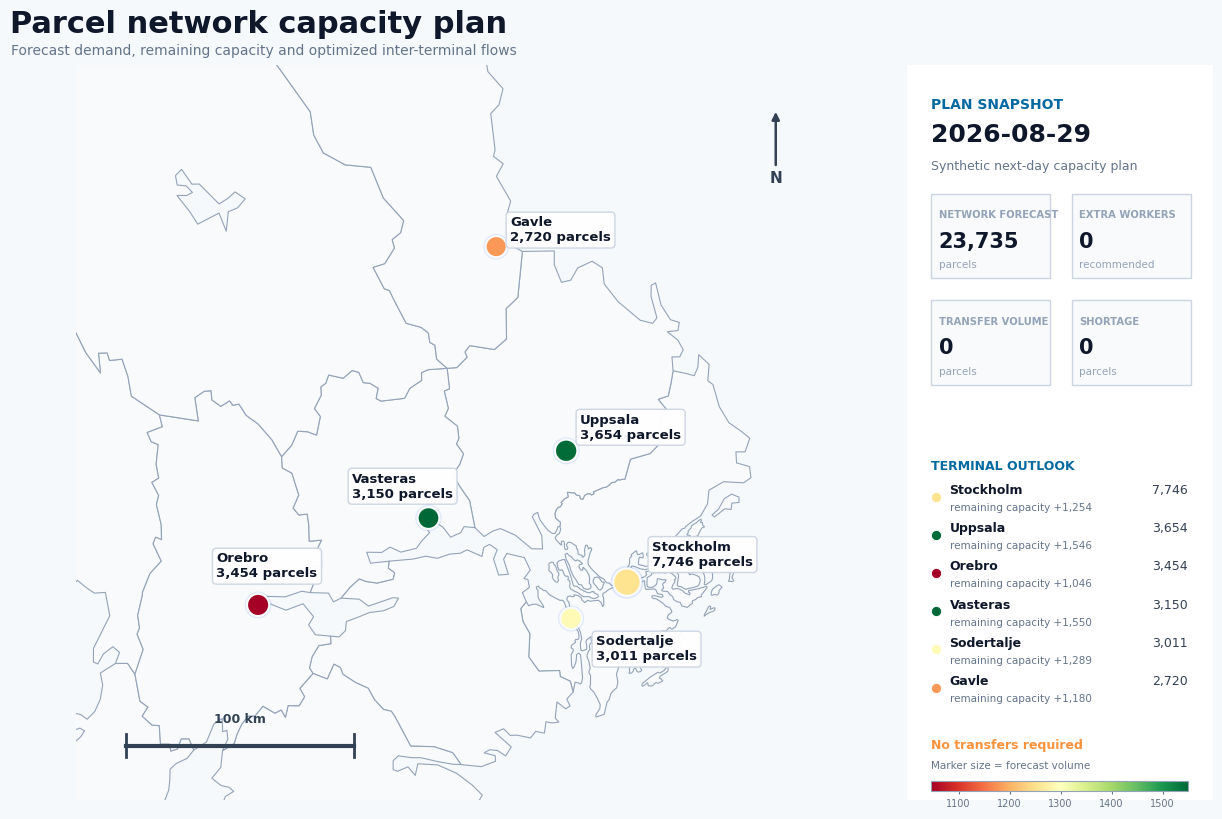

In [55]:
county_path = DATA_DIR / "shape_svenska_260225" / "LanSweref99TM.zip"
sweden_counties = gpd.read_file(f"zip://{county_path.resolve()}")

map_data = plan.merge(
    terminals[["terminal", "lat", "lon"]],
    on="terminal",
)
terminal_points = gpd.GeoDataFrame(
    map_data,
    geometry=gpd.points_from_xy(map_data["lon"], map_data["lat"]),
    crs="EPSG:4326",
).to_crs(sweden_counties.crs)
terminal_lookup = terminal_points.set_index("terminal")

fig = plt.figure(figsize=(13, 8.5), facecolor="#F6F9FC")
layout = fig.add_gridspec(1, 2, width_ratios=[3.4, 1.15], wspace=0.02)
ax = fig.add_subplot(layout[0, 0])
ax_info = fig.add_subplot(layout[0, 1])
ax.set_facecolor("#DDEBF5")
ax_info.set_facecolor("#FFFFFF")
sweden_counties.plot(
    ax=ax,
    color="#F8FAFC",
    edgecolor="#94A3B8",
    linewidth=0.8,
    zorder=1,
)

for _, row in transfer_df.iterrows():
    origin = terminal_lookup.loc[row["from"], "geometry"]
    destination = terminal_lookup.loc[row["to"], "geometry"]
    ax.annotate(
        "",
        xy=(destination.x, destination.y),
        xytext=(origin.x, origin.y),
        arrowprops={
            "arrowstyle": "-|>",
            "color": "#FB923C",
            "linewidth": 1.4 + row["parcels"] / 500,
            "alpha": 0.8,
            "shrinkA": 12,
            "shrinkB": 12,
        },
        zorder=2,
    )

marker_sizes = 150 + 240 * (
    terminal_points["forecast_volume"]
    / terminal_points["forecast_volume"].max()
)
capacity_norm = plt.Normalize(
    terminal_points["remaining_capacity"].min(),
    terminal_points["remaining_capacity"].max(),
)
capacity_cmap = plt.get_cmap("RdYlGn")
ax.scatter(
    terminal_points.geometry.x,
    terminal_points.geometry.y,
    s=marker_sizes * 1.45,
    color="#2563EB",
    alpha=0.12,
    linewidth=0,
    zorder=2,
)
terminal_points.plot(
    ax=ax,
    column="remaining_capacity",
    cmap=capacity_cmap,
    norm=capacity_norm,
    markersize=marker_sizes,
    edgecolor="#F8FAFC",
    linewidth=1.6,
    zorder=3,
)

label_offsets = {
    "Stockholm": (18, 12),
    "Uppsala": (10, 9),
    "Vasteras": (-55, 15),
    "Sodertalje": (18, -30),
    "Orebro": (-30, 20),
    "Gavle": (10, 4),
}
for _, row in terminal_points.iterrows():
    offset = label_offsets.get(row["terminal"], (8, 8))
    ax.annotate(
        f"{row['terminal']}\n{row['forecast_volume']:,.0f} parcels",
        xy=(row.geometry.x, row.geometry.y),
        xytext=offset,
        textcoords="offset points",
        fontsize=9.5,
        fontweight="bold",
        color="#0F172A",
        bbox={"boxstyle": "round,pad=0.3", "fc": "#FFFFFF", "ec": "#CBD5E1", "alpha": 0.96},
        zorder=4,
    )

xmin, ymin, xmax, ymax = terminal_points.total_bounds
padding = 80_000
ax.set_xlim(xmin - padding, xmax + padding)
ax.set_ylim(ymin - padding, ymax + padding)

# Fixed-map navigation aids (EPSG:3006 uses metres).
scale_x = xmin - padding + 22_000
scale_y = ymin - padding + 24_000
ax.plot([scale_x, scale_x + 100_000], [scale_y, scale_y], color="#334155", linewidth=3, zorder=5)
ax.plot([scale_x, scale_x], [scale_y - 5_000, scale_y + 5_000], color="#334155", linewidth=2, zorder=5)
ax.plot([scale_x + 100_000, scale_x + 100_000], [scale_y - 5_000, scale_y + 5_000], color="#334155", linewidth=2, zorder=5)
ax.text(scale_x + 50_000, scale_y + 10_000, "100 km", ha="center", color="#334155", fontsize=9, fontweight="bold")
ax.annotate(
    "N",
    xy=(0.955, 0.94),
    xytext=(0.955, 0.84),
    xycoords="axes fraction",
    ha="center",
    color="#334155",
    fontsize=11,
    fontweight="bold",
    arrowprops={"arrowstyle": "-|>", "color": "#334155", "linewidth": 1.8},
    zorder=6,
)
ax.set_axis_off()

# Management snapshot beside the map.
ax_info.set_xlim(0, 1)
ax_info.set_ylim(0, 1)
ax_info.set_xticks([])
ax_info.set_yticks([])
for spine in ax_info.spines.values():
    spine.set_visible(False)

ax_info.text(0.08, 0.94, "PLAN SNAPSHOT", color="#0369A1", fontsize=10, fontweight="bold")
ax_info.text(0.08, 0.895, str(next_date.date()), color="#0F172A", fontsize=18, fontweight="bold")
ax_info.text(0.08, 0.858, "Synthetic next-day capacity plan", color="#64748B", fontsize=9)

snapshot_metrics = [
    ("NETWORK FORECAST", f"{plan['forecast_volume'].sum():,.0f}", "parcels"),
    ("EXTRA WORKERS", f"{plan['extra_workers'].sum():,.0f}", "recommended"),
    ("TRANSFER VOLUME", f"{transfer_df['parcels'].sum() if not transfer_df.empty else 0:,.0f}", "parcels"),
    ("SHORTAGE", f"{plan['shortage'].sum():,.0f}", "parcels"),
]
for index, (label, value, unit) in enumerate(snapshot_metrics):
    row = index // 2
    column = index % 2
    x0 = 0.08 + column * 0.46
    y0 = 0.71 - row * 0.145
    card = plt.Rectangle((x0, y0), 0.39, 0.115, facecolor="#F8FAFC", edgecolor="#CBD5E1", linewidth=1)
    ax_info.add_patch(card)
    ax_info.text(x0 + 0.025, y0 + 0.082, label, color="#94A3B8", fontsize=7.2, fontweight="bold")
    ax_info.text(x0 + 0.025, y0 + 0.042, value, color="#0F172A", fontsize=15, fontweight="bold")
    ax_info.text(x0 + 0.025, y0 + 0.014, unit, color="#94A3B8", fontsize=7.5)

ax_info.text(0.08, 0.45, "TERMINAL OUTLOOK", color="#0369A1", fontsize=9, fontweight="bold")
ranked_terminals = terminal_points.sort_values("forecast_volume", ascending=False)
for index, (_, row) in enumerate(ranked_terminals.iterrows()):
    y = 0.405 - index * 0.052
    dot_color = capacity_cmap(capacity_norm(row["remaining_capacity"]))
    ax_info.scatter(0.095, y + 0.008, s=55, color=dot_color, edgecolor="white", linewidth=0.7)
    ax_info.text(0.14, y + 0.012, row["terminal"], color="#0F172A", fontsize=9, fontweight="semibold")
    ax_info.text(0.92, y + 0.012, f"{row['forecast_volume']:,.0f}", ha="right", color="#334155", fontsize=9)
    ax_info.text(0.14, y - 0.011, f"remaining capacity {row['remaining_capacity']:+,.0f}", color="#64748B", fontsize=7.5)

transfer_status = "No transfers required" if transfer_df.empty else f"{len(transfer_df)} optimized transfer links"
ax_info.text(0.08, 0.07, transfer_status, color="#FB923C", fontsize=9, fontweight="bold")
ax_info.text(0.08, 0.043, "Marker size = forecast volume", color="#64748B", fontsize=7.5)

colorbar_axis = ax_info.inset_axes([0.08, 0.012, 0.84, 0.014])
colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=capacity_norm, cmap=capacity_cmap),
    cax=colorbar_axis,
    orientation="horizontal",
)
colorbar.ax.tick_params(colors="#64748B", labelsize=7, length=2)
colorbar.outline.set_edgecolor("#94A3B8")

fig.suptitle(
    "Parcel network capacity plan",
    x=0.055,
    y=0.975,
    ha="left",
    color="#0F172A",
    fontsize=22,
    fontweight="bold",
)
fig.text(
    0.056,
    0.922,
    "Forecast demand, remaining capacity and optimized inter-terminal flows",
    color="#64748B",
    fontsize=10,
)
plt.subplots_adjust(left=0.04, right=0.98, top=0.91, bottom=0.045)
plt.show()


## 10. Decision-support summary

The purpose of the project is not to claim that one forecasting algorithm or one optimization formulation is universally best.

The important workflow is:

**raw parcel data → demand pattern → forecast → capacity gap → optimized action → operational recommendation**

A useful management summary would answer:

- Which terminals are expected to exceed normal capacity?
- How much extra staffing is justified?
- Can some overflow be moved to nearby terminals?
- What is the expected cost of the plan?
- Is any shortage still unresolved?
- Which forecasts are most uncertain and therefore need manual attention?

This creates a direct connection between data science and logistics operations.


In [51]:
total_forecast = plan["forecast_volume"].sum()
total_workers = plan["extra_workers"].sum()
total_shortage = plan["shortage"].sum()
total_transfers = transfer_df["parcels"].sum() if not transfer_df.empty else 0

print(f"Planning date: {next_date.date()}")
print(f"Forecast network volume: {total_forecast:,.0f} parcels")
print(f"Recommended extra workers: {total_workers}")
print(f"Recommended transferred volume: {total_transfers:,.0f} parcels")
print(f"Remaining shortage: {total_shortage:,.0f} parcels")
print(f"Estimated optimized cost: {result.fun:,.0f} SEK")


Planning date: 2026-08-29
Forecast network volume: 23,735 parcels
Recommended extra workers: 0
Recommended transferred volume: 0 parcels
Remaining shortage: 0 parcels
Estimated optimized cost: 0 SEK


## 11. Limitations and next steps

This is intentionally a compact portfolio case study. A production system would need substantially more work.

### Forecasting

Possible improvements:

- longer historical series,
- Swedish public-holiday and campaign calendars,
- weather and disruption signals,
- probabilistic forecasts instead of point forecasts,
- forecast intervals,
- terminal-level and network-level hierarchical reconciliation,
- systematic hyperparameter tuning,
- monitoring for model drift.

### Optimization

The current model simplifies real logistics. Future versions could include:

- shift scheduling,
- vehicle capacity,
- line-haul departure times,
- service-level constraints,
- explicit origin-destination parcel flows,
- route optimization,
- terminal opening hours,
- trailer availability,
- transfer lead time,
- stochastic or robust optimization using forecast uncertainty.

### Geospatial analysis

A richer network model could include:

- road-network travel times rather than straight-line distance,
- delivery-area polygons,
- customer-density surfaces,
- route clusters,
- terminal catchment optimization.

## What this case study demonstrates

- time-series forecasting,
- feature engineering,
- model benchmarking,
- Python / pandas / NumPy / scikit-learn,
- mixed-integer optimization,
- operational capacity planning,
- resource allocation,
- geospatial visualization,
- translating analytical output into practical decision support.
